# Section 4.1.4 — Conditioning of the kernel matrix

For each design we form the Matérn-5/2 Gram matrix at a fixed length scale and report its spectral condition number $\kappa(K)$ versus $N$, for $d=2,3,5,7$. The condition number is an essentially monotone decreasing function of the separation radius, validating the numerical-stability rationale for quasi-uniform designs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from lattice_qmc import KorobovLattice, ExplicitRank1Lattice
from lattice_qmc.utils import compute_separation_radius_fast
from lattice_qmc.baselines import maximin_lhd, matern52_gram

try:
    import qmcpy as qp
    QMCPY_AVAILABLE = True
except ImportError:
    QMCPY_AVAILABLE = False

plt.rcParams.update({
    'font.size': 12, 'font.family': 'serif', 'axes.labelsize': 14,
    'legend.fontsize': 10, 'figure.figsize': (7, 5), 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'lines.linewidth': 2, 'lines.markersize': 8,
})

# Load optimal Korobov parameters
korobov_params = np.load('data/korobov_optimal_parameters.npy', allow_pickle=True).item()
korobov_primes = korobov_params['primes']
optimal_generators = korobov_params['optimal_generators']

STYLES = {
    'korobov':  {'color': '#1f77b4', 'marker': 'o', 'label': 'Korobov (ours)'},
    'explicit': {'color': '#d62728', 'marker': 's', 'label': 'Explicit (ours)'},
    'lhd':      {'color': '#ff7f0e', 'marker': 'P', 'label': 'Maximin LHD'},
    'random':   {'color': '#7f7f7f', 'marker': 'x', 'label': 'Random'},
    'halton':   {'color': '#2ca02c', 'marker': '^', 'label': 'Halton'},
    'sobol':    {'color': '#9467bd', 'marker': 'D', 'label': "Sobol'"},
}
print('Setup complete.')


Setup complete.


In [2]:
def design_points(method, n, d):
    if method == 'halton':
        return qp.Halton(d, seed=42).gen_samples(n)
    if method == 'sobol':
        return qp.Sobol(d, seed=42).gen_samples(n)
    if method == 'lhd':
        return maximin_lhd(n, d, seed=2024)
    if method == 'random':
        return np.random.default_rng(42).random((n, d))
    raise ValueError(method)
print('Generators loaded.')


Generators loaded.


In [3]:
LENGTH_SCALE = 0.5
POWERS = [16, 32, 64, 128, 256, 512]
N_CAP = 1100
EXPL_M = {2: range(3, 12), 3: range(3, 13), 5: range(3, 12), 7: range(3, 9)}

def cond(points):
    K = matern52_gram(points, length_scale=LENGTH_SCALE)
    s = np.linalg.svd(K, compute_uv=False)
    return float(s[0] / max(s[-1], 1e-300))


In [4]:
def run_dim(d):
    res = {m: {'N': [], 'cond': [], 'q': []} for m in STYLES}
    for idx, N in enumerate(korobov_primes[2:9]):
        if N > N_CAP:
            continue
        P = KorobovLattice(d=d, N=int(N), generator=int(optimal_generators[d][2:9][idx])).points
        res['korobov']['N'].append(int(N)); res['korobov']['cond'].append(cond(P))
        res['korobov']['q'].append(compute_separation_radius_fast(P, toroidal=True))
    alpha = np.array([2.0 ** (j / (d + 1)) for j in range(1, d + 1)])
    seen = set()
    for m in EXPL_M[d]:
        lat = ExplicitRank1Lattice(d=d, m=m, alpha=alpha)
        if lat.Q in seen or lat.Q < 3 or lat.Q > N_CAP:
            continue
        seen.add(lat.Q)
        res['explicit']['N'].append(int(lat.Q)); res['explicit']['cond'].append(cond(lat.points))
        res['explicit']['q'].append(compute_separation_radius_fast(lat.points, toroidal=True))
    for method in ['random', 'halton', 'sobol', 'lhd']:
        for n in POWERS:
            P = design_points(method, n, d)
            res[method]['N'].append(n); res[method]['cond'].append(cond(P))
            res[method]['q'].append(compute_separation_radius_fast(P, toroidal=False))
    return res


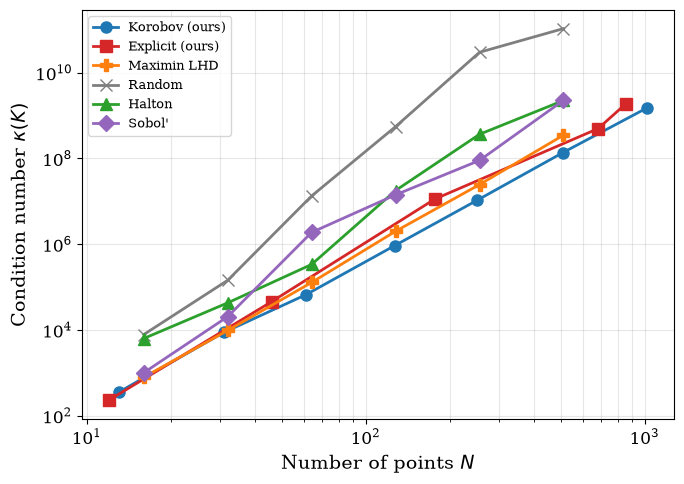

d=2: at N~256, korobov q=0.0327 kappa=1.06e+07


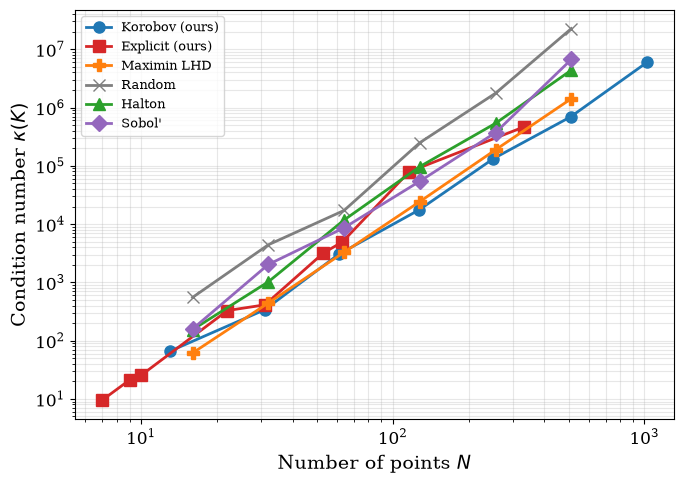

d=3: at N~256, korobov q=0.0768 kappa=1.33e+05


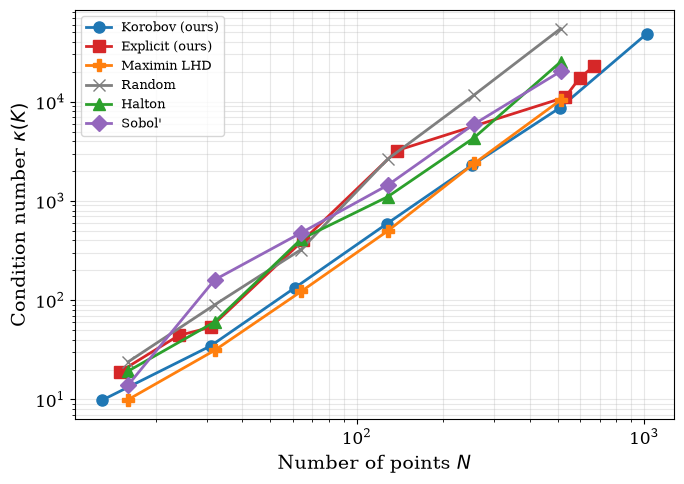

d=5: at N~256, korobov q=0.1814 kappa=2.28e+03


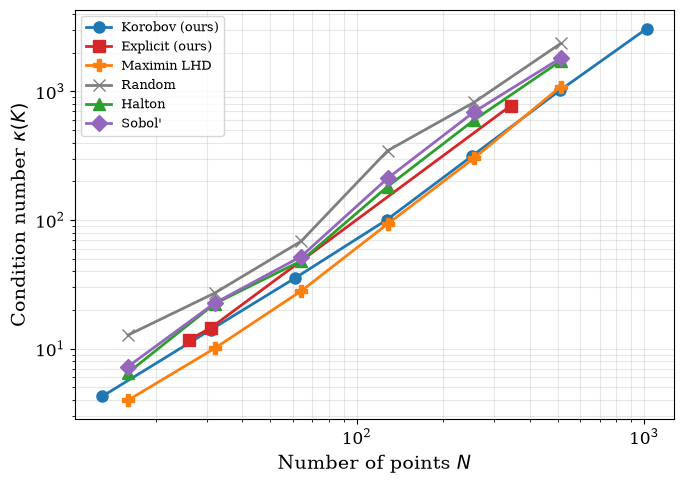

d=7: at N~256, korobov q=0.2506 kappa=3.13e+02


In [5]:
def plot_dim(res, d):
    plt.figure(figsize=(7, 5))
    for m, st in STYLES.items():
        if res[m]['N']:
            order = np.argsort(res[m]['N'])
            N = np.array(res[m]['N'])[order]; cv = np.array(res[m]['cond'])[order]
            plt.loglog(N, cv, marker=st['marker'], color=st['color'], label=st['label'])
    plt.xlabel('Number of points $N$'); plt.ylabel(r'Condition number $\kappa(K)$')
    plt.legend(loc='best', fontsize=9); plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.savefig(f'Condition_number_d={d}.png', dpi=300)
    plt.show()

for d in [2, 3, 5, 7]:
    res = run_dim(d)
    plot_dim(res, d)
    i = int(np.argmin([abs(n - 256) for n in res['korobov']['N']]))
    print(f"d={d}: at N~256, korobov q={res['korobov']['q'][i]:.4f} kappa={res['korobov']['cond'][i]:.2e}")
